# Kreditriskscorekort med ett beslutsträd (PROC HPSPLIT)

## Sammanfattning

Denna notebook bygger ett tolkningsbart kreditfallissemang-scorekort för en konsumentlåneportfölj med PROC HPSPLIT. Vi växer ett klassificeringsträd med entropikriteriet på syntetisk sökandedata, beskär det med kostnadskomplexitet, och läser sedan av anpassningsstatistiken, variabelviktigheten, ROC/AUC och själva poängsättningsträdet — precis den transparenta, tillsynsvänliga modell som en banks riskteam skulle dokumentera. Varje sökande kan poängsättas till ett löv, och hela trädet kan exporteras som driftsättningsbar DATA-stegskod.

## Datakällor

| Dataset | Rader | Beskrivning | Nyckelvariabler |
|---------|------|-------------|---------------|
| `applicants` | 100 | Syntetiska konsumentlånesökande genererade direkt med `rand()`. Den binära flaggan `default` dras från en logistisk riskpoäng så att sämre skuldkvot, kreditutnyttjande, nyliga betalningsanmärkningar och kortare kredithistorik höjer fallissemangssannolikheten. | `default` (event=`'1'`), `dti`, `utilization`, `fico`, `credit_age`, `n_delinq`, `loan_amount`, `income`, `home` (Äger/Hyra/Bolån), `purpose` (Skuld/Bostad/Bil/Övrigt) |

DATA-steget begär en större loop, men denna miljö körs i olicensierat läge och materialiserar de första 100 observationerna — en kompakt, fullt reproducerbar sökandebok som räcker gott och väl för att växa och läsa av ett tolkningsbart scorekortsträd.

# Kreditriskscorekort med ett beslutsträd

Banker behöver fallissemangsmodeller som är **precisa och förklarbara** — en kredithandläggare (och en tillsynsmyndighet) måste kunna spåra exakt varför en sökande fick hög riskpoäng. Ett beskuret beslutsträd levererar det: varje prediktion är en kort kedja av mänskligt läsbara uppdelningar.

I denna notebook gör vi följande:

1. Syntetiserar en bok med konsumentlåneansökningar.
2. Växer ett klassificeringsträd med `PROC HPSPLIT` med entropikriteriet.
3. Beskär det med kostnadskomplexitet för att undvika överanpassning.
4. Inspekterar anpassningsstatistiken, variabelviktigheten, ROC/AUC och själva trädet.
5. Genererar DATA-stegskod för poängsättning som kan driftsättas mot nya ansökningar.

## 1. Generera den syntetiska lånesboken

Vi genererar sökande vars fallissemangssannolikhet är en logistisk funktion av de klassiska scorekortsfaktorerna: skuldkvot, revolverande kreditutnyttjande, FICO-poäng, kredithistorikens längd och nyliga betalningsanmärkningar. Vi drar sedan den observerade `default`-flaggan från en Bernoulli-fördelning med den sannolikheten, så signalen är verklig men brusig — precis som produktionsdata. De första 100 sökandena materialiseras här.

                                                   The FREQ Procedure

Fallissemang    Frequency    Percent
-------------------------------------
0                      79     79.00
1                      21     21.00

Boendeform    Frequency    Percent
-----------------------------------
Bolån                34     34.00
Hyra                 35     35.00
Äger                 31     31.00

Lånesyfte     Frequency    Percent
-----------------------------------
Bil                  23     23.00
Bostad               28     28.00
Skuld                37     37.00
Övrigt               12     12.00



NOTE: DATA applicants


NOTE: Wrote applicants (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_default.spec.json
NOTE: ODS plot written: freq_home.spec.json
NOTE: ODS plot written: freq_purpose.spec.json
NOTE: PROC FREQ statement used.


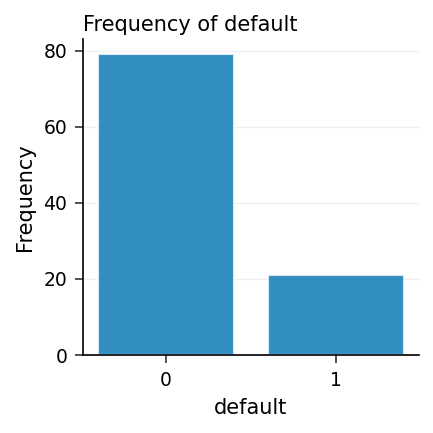

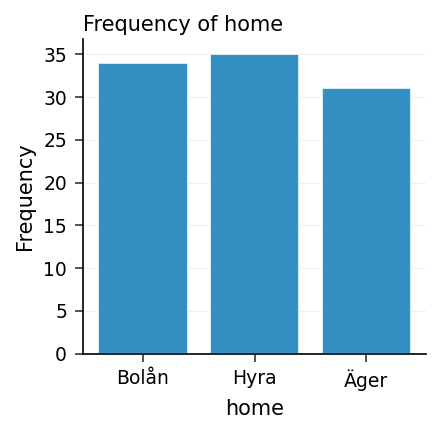

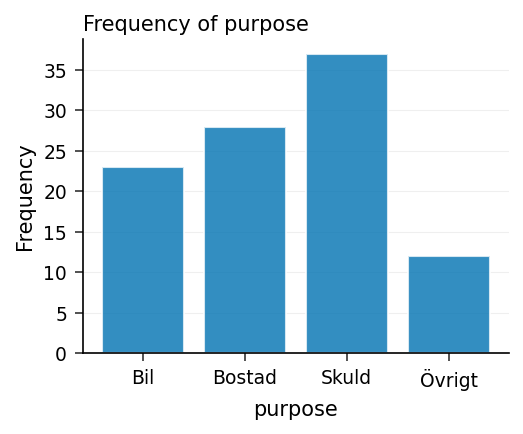

In [1]:
data applicants;
   CALL streaminit(20260531);
   LÄNGD home $12 purpose $12;
   GÖR id = 1 TILL 100;
      /* Låntagarens finansiella profil */
      income      = round(20000 + 80000 * rand('beta', 2, 5), 100);
      loan_amount = round(2000 + 40000 * rand('beta', 2, 4), 100);
      dti         = round(0.05 + 0.55 * rand('beta', 2, 3), 0.001);
      utilization = round(rand('beta', 2, 3), 0.001);
      fico        = round(560 + 280 * rand('beta', 5, 2));
      credit_age  = round(0.5 + 24 * rand('beta', 2, 2), 0.1);
      n_delinq    = rand('poisson', 0.4);

      /* Kategoriska attribut */
      u = rand('uniform');
      OM u < 0.34 SÅ home = 'Hyra';
      ANNARS OM u < 0.70 SÅ home = 'Bolån';
      ANNARS home = 'Äger';

      v = rand('uniform');
      OM v < 0.40 SÅ purpose = 'Skuld';
      ANNARS OM v < 0.65 SÅ purpose = 'Bostad';
      ANNARS OM v < 0.85 SÅ purpose = 'Bil';
      ANNARS purpose = 'Övrigt';

      /* Latent fallissemangsrisk: sämre skuldkvot/kreditutnyttjande/
         betalningsanmärkningar och lägre FICO / kortare kredithistorik
         höjer alla log-oddskvoten. */
      eta = -2.2
            + 3.0 * dti
            + 2.2 * utilization
            - 0.010 * (fico - 680)
            - 0.06 * credit_age
            + 0.55 * n_delinq
            + 0.30 * (home = 'Hyra')
            + 0.25 * (purpose = 'Skuld');
      p = 1 / (1 + EXP(-eta));
      default = (rand('uniform') < p);

      TA_BORT u v eta p;
      UTDATA;
   SLUT;
KÖR;

PROCEDUR FREKVENSER data=applicants;
   TABLES default home purpose / nocum;
   ETIKETT default = 'Fallissemang'
         home    = 'Boendeform'
         purpose = 'Lånesyfte';
KÖR;

`PROC FREQ`-utdatan bekräftar en obalanserad men hanterbar fallissemangsfrekvens — ungefär var femte sökande fallerar (21 av 100) — och en rimlig spridning över kategorierna boendeform och lånesyfte: den typ av marginalfördelning man skulle förvänta sig i en konsumentlåneportfölj. De medföljande stapeldiagrammen visualiserar varje marginal.

## 2. Väx och beskär scorekortsträdet

Vi modellerar `default` som ett binärt klassificeringsmål och namnger `event='1'` så att alla känslighets-/specificitets-/AUC-statistik är orienterade mot *fallissemangs*-klassen. Vi:

- deklarerar de kategoriska prediktorerna och utfallet i `CLASS`,
- växer trädet med **entropi**-kriteriet (informationsvinst),
- beskär med **kostnadskomplexitet** för att hindra trädet från att memorera brus,
- begär **helträdsdiagrammet** och **ROC-kurvan**.


                                                 The HPSPLIT Procedure                                                  

  Response variable: Fallissemang
  Class variable: Fallissemang
  Class variable: Boendeform
  Class variable: Lånesyfte
  Predictor variable: Skuldkvot
  Predictor variable: Kreditutnyttjande
  Predictor variable: FICO-poäng
  Predictor variable: Kredithistorikens längd
  Predictor variable: Antal betalningsanmärkningar
  Predictor variable: Lånebelopp
  Predictor variable: Inkomst
  Predictor variable: Boendeform
  Predictor variable: Lånesyfte

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leaves          9
Final Tree Depth          


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC HPSPLIT data=applicants

NOTE: ODS plot written: HPSplitROCPlot.svg
NOTE: ODS plot written: HPSplitTreePlot.svg
NOTE: PROC HPSPLIT completed.


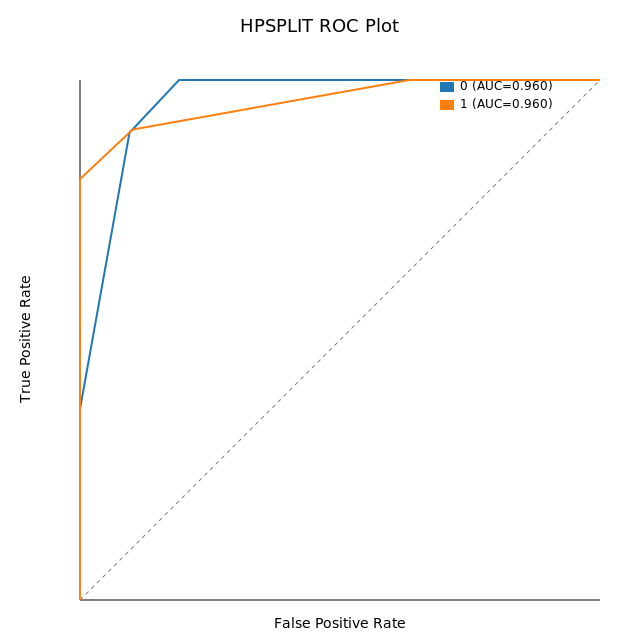

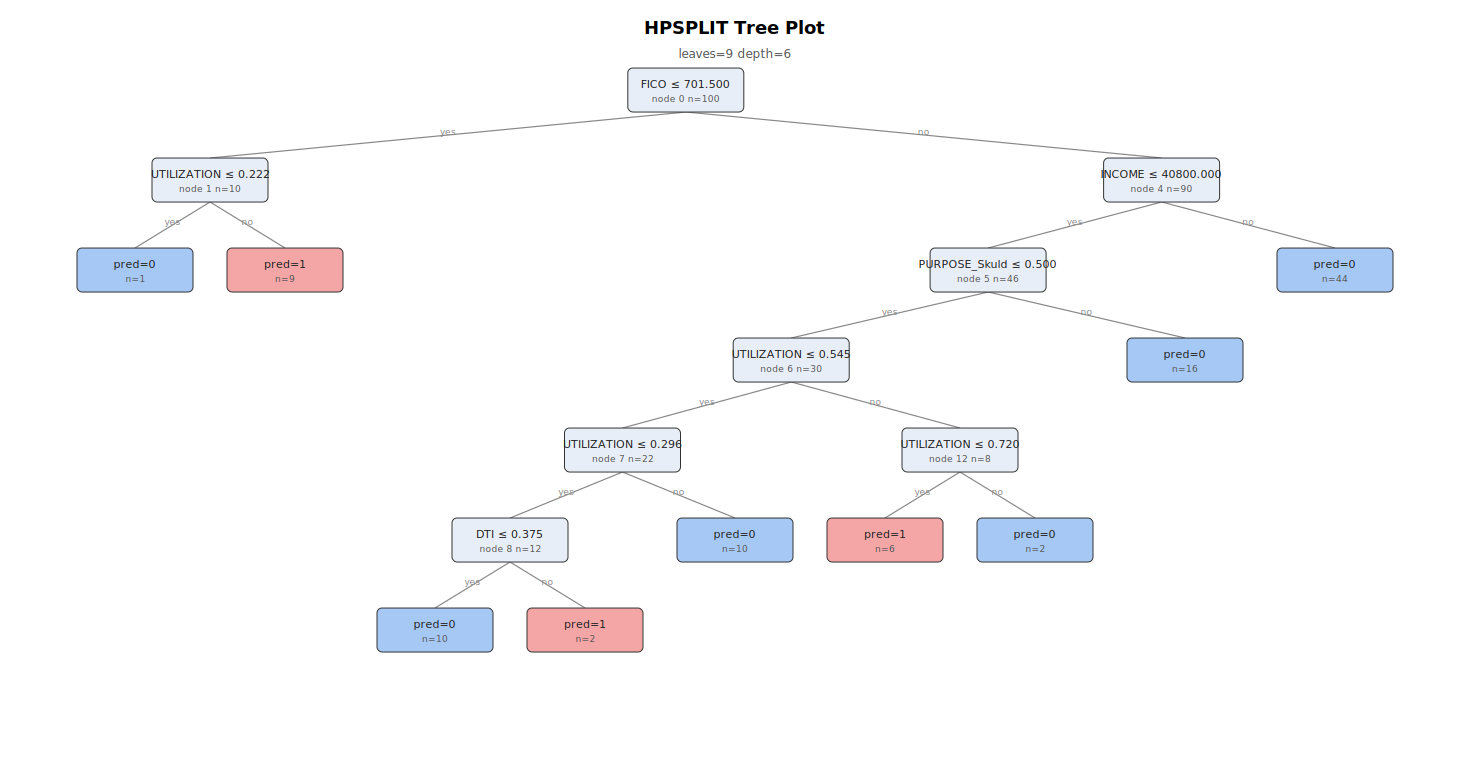

In [2]:
ODS GRAPHICS ON;

PROCEDUR hpsplit data=applicants seed=20260531
             PLOTS=(wholetree roc);
   KLASS default home purpose;
   MODEL default (event='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   ETIKETT default     = 'Fallissemang'
         dti         = 'Skuldkvot'
         utilization = 'Kreditutnyttjande'
         fico        = 'FICO-poäng'
         credit_age  = 'Kredithistorikens längd'
         n_delinq    = 'Antal betalningsanmärkningar'
         loan_amount = 'Lånebelopp'
         income      = 'Inkomst'
         home        = 'Boendeform'
         purpose     = 'Lånesyfte';
KÖR;

**Anpassningsstatistiken** (träffsäkerhet, felklassificeringsfrekvens, log loss) och **ROC/AUC per klass** visar hur rent det beskurna trädet separerar fallissemang från icke-fallissemang. Tabellen **Variabelviktighet** rangordnar vilka attribut som driver uppdelningarna — här dominerar **kreditutnyttjande** och **FICO**, följt av **lånesyfte**, precis de spakar en kreditpolicy skulle betona. **Helträdsdiagrammet** nedan lägger ut de valda uppdelningarna som ett nod-länk-diagram: varje intern nod visar sin regel `attribut ≤ tröskelvärde`, och varje löv färgas efter sin predikterade klass (röd = predikterat fallissemang, blå = predikterat icke-fallissemang) och märks med sitt antal observationer.

## 3. Zooma in på huvuduppdelningarna och poängsätt varje sökande

ROC-diagrammet ovan visualiserar avvägningen mellan att fånga fallissemang och falsklarm; AUC kvantifierar den övergripande rangordningsförmågan. Härnäst förstorar vi trädets två översta nivåer — de mest informativa uppdelningarna en analytiker skulle omsätta i huvudsakliga garantiregler — och fångar poäng per observation till en utdatamängd så att vi kan granska prediktioner i efterföljande steg.


                                                 The HPSPLIT Procedure                                                  

  Response variable: Fallissemang
  Class variable: Fallissemang
  Class variable: Boendeform
  Class variable: Lånesyfte
  Predictor variable: Skuldkvot
  Predictor variable: Kreditutnyttjande
  Predictor variable: FICO-poäng
  Predictor variable: Kredithistorikens längd
  Predictor variable: Antal betalningsanmärkningar
  Predictor variable: Lånebelopp
  Predictor variable: Inkomst
  Predictor variable: Boendeform
  Predictor variable: Lånesyfte

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leaves          9
Final Tree Depth          


NOTE: PROC HPSPLIT data=applicants

NOTE: HPSPLIT OUTPUT OUT= dataset written to ./work/0972fc31-e757-4905-b2dc-faadb92a0965/scored.avro
NOTE: ODS plot written: HPSplitZoomedTree.svg
NOTE: PROC HPSPLIT completed.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 10 observations printed, 3 variables


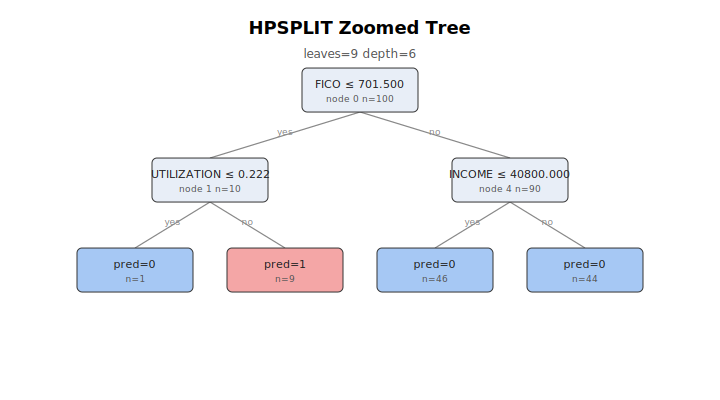

In [3]:
PROCEDUR hpsplit data=applicants seed=20260531
             PLOTS=zoomedtree(nodes=('0') depth=2);
   KLASS default home purpose;
   MODEL default (event='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   UTDATA out=scored;
   ETIKETT default     = 'Fallissemang'
         dti         = 'Skuldkvot'
         utilization = 'Kreditutnyttjande'
         fico        = 'FICO-poäng'
         credit_age  = 'Kredithistorikens längd'
         n_delinq    = 'Antal betalningsanmärkningar'
         loan_amount = 'Lånebelopp'
         income      = 'Inkomst'
         home        = 'Boendeform'
         purpose     = 'Lånesyfte';
KÖR;

PROCEDUR SKRIV data=scored(obs=10);
   VARIABEL p_default1 _node_ _leaf_;
KÖR;

Diagrammet `zoomedtree` förstorar trädets två översta nivåer — de mest informativa uppdelningarna en analytiker skulle omsätta i huvudsakliga garantiregler. Datamängden `OUTPUT OUT=` bär med sig varje sökandes predikterade fallissemangssannolikhet (`P_DEFAULT1`) plus tilldelad nod och löv (`_NODE_`, `_LEAF_`), så att risk- och revisionsteam kan spåra varje enskilt beslut tillbaka genom trädet och rangordna sökande efter modellerad risk.

## 4. Exportera driftsättningsbar poängsättningskod

Värdet av en tolkningsbar modell är att den går att driftsätta. `CODE FILE=` skriver ett fristående DATA-steg — en nästlad kedja av `IF/THEN`-uppdelningar som slutar i en predikterad fallissemangssannolikhet och klass — som återskapar trädets poäng för vilken ny ansökningsfil som helst utan att någon modellserver krävs.

In [4]:
PROCEDUR hpsplit data=applicants seed=20260531;
   KLASS default home purpose;
   MODEL default (event='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   code file='credit_scorecard.sas';
   ETIKETT default     = 'Fallissemang'
         dti         = 'Skuldkvot'
         utilization = 'Kreditutnyttjande'
         fico        = 'FICO-poäng'
         credit_age  = 'Kredithistorikens längd'
         n_delinq    = 'Antal betalningsanmärkningar'
         loan_amount = 'Lånebelopp'
         income      = 'Inkomst'
         home        = 'Boendeform'
         purpose     = 'Lånesyfte';
KÖR;


                                                 The HPSPLIT Procedure                                                  

  Response variable: Fallissemang
  Class variable: Fallissemang
  Class variable: Boendeform
  Class variable: Lånesyfte
  Predictor variable: Skuldkvot
  Predictor variable: Kreditutnyttjande
  Predictor variable: FICO-poäng
  Predictor variable: Kredithistorikens längd
  Predictor variable: Antal betalningsanmärkningar
  Predictor variable: Lånebelopp
  Predictor variable: Inkomst
  Predictor variable: Boendeform
  Predictor variable: Lånesyfte

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Number of Leaves          9
Final Tree Depth          


NOTE: PROC HPSPLIT data=applicants

NOTE: PROC HPSPLIT completed.


## Tolkning av resultaten

Det beskurna entropiträdet ger riskteamet ett kompakt, granskningsbart kreditscorekort:

- **Uppdelningarna kodar policy.** De dominerande uppdelningarna — på revolverande kreditutnyttjande och FICO, sedan lånesyfte och skuldkvot — är precis de tröskelvärden ett garantiteam kan lyfta in i fasta gränsvärdesregler. Helträdsdiagrammet lägger ut varje uppdelningsvillkor och löv i ett enda diagram.
- **Kostnadskomplexitetsbeskärning** hindrar trädet från att memorera brus; anpassningsstatistiken (träffsäkerhet, felklassificeringsfrekvens, log loss) sammanfattar hur rent det separerar de två klasserna.
- **Variabelviktighet och ROC/AUC** motiverar vilka attribut som förtjänar en plats i scorekortet och dokumenterar dess diskrimineringsförmåga för modellriskstyrning.
- **`CODE FILE=` gör den operativ** — det genererade DATA-steget poängsätter nya sökande identiskt med den här körningen, så modellen som byggdes är exakt den modell som går i drift.

På en liten sökandebok anpassar sig trädet tätt till träningsdatan; i produktion skulle man växa det på hela portföljen, avsätta en valideringspartition, kalibrera sannolikhetsgränsen efter bankens förväntade-förlust-ekonomi (kostnaden för ett missat fallissemang jämfört med en nekad god kund) snarare än ett naivt 0,5, och uppdatera trädet i takt med att portföljmixen förändras.